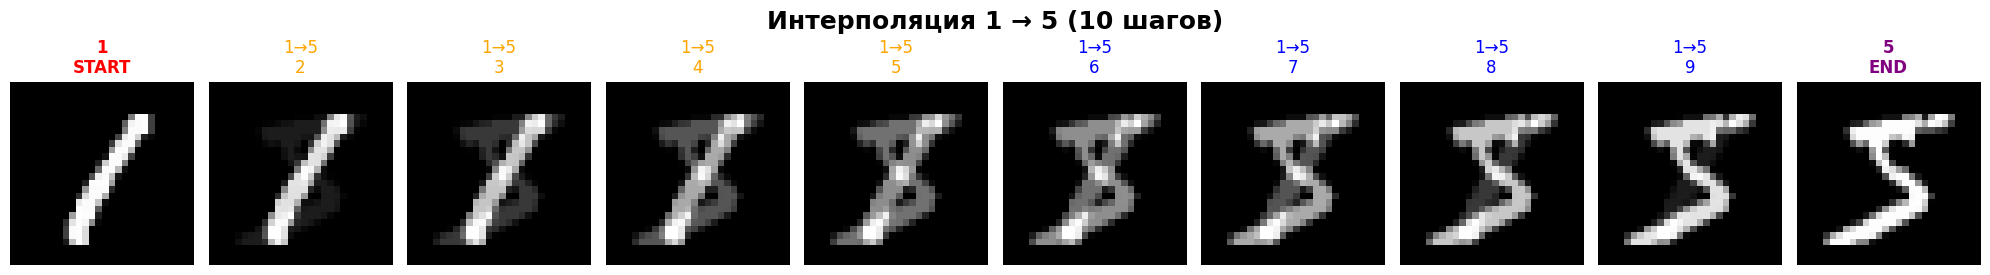

ДЕТАЛИ ИНТЕРПОЛЯЦИИ:
Всего шагов: 10
Маршрут: 1 → 5

РАСПРЕДЕЛЕНИЕ ШАГОВ:
• Шаг 1:    Начало - цифра 1
• Шаги 2-9: Плавный переход 1 → 5
• Шаг 10:   Конец - цифра 5

ИТОГО: 10 шагов от цифры 1 до цифры 5


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Загружаем данные MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

def find_digit_samples(digits):
    samples = []
    for digit in digits:
        indices = np.where(y_train == digit)[0]
        sample = x_train[indices[0]]
        samples.append(sample)
    return samples

digit_1, digit_5 = find_digit_samples([1, 5])

def linear_interpolate(img1, img2, num_steps):
    """Линейная интерполяция между двумя изображениями"""
    interpolated = []
    for alpha in np.linspace(0, 1, num_steps):
        interp_img = (1 - alpha) * img1 + alpha * img2
        interpolated.append(interp_img)
    return interpolated

interpolated_images = linear_interpolate(digit_1, digit_5, 10)

fig, axes = plt.subplots(1, 10, figsize=(20, 3))

colors = ['red', 'orange', 'orange', 'orange', 'orange',
          'blue', 'blue', 'blue', 'blue', 'purple']

for i, (img, color) in enumerate(zip(interpolated_images, colors)):
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')

    if i == 0:
        axes[i].set_title('1\nSTART', color=color, fontweight='bold')
    elif i == 9:
        axes[i].set_title('5\nEND', color=color, fontweight='bold')
    elif i < 5:
        axes[i].set_title(f'1→5\n{i+1}', color=color)
    else:
        axes[i].set_title(f'1→5\n{i+1}', color=color)

    axes[i].patch.set_edgecolor(color)
    axes[i].patch.set_linewidth(3)

plt.suptitle('Интерполяция 1 → 5 (10 шагов)', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

print("=" * 50)
print("ДЕТАЛИ ИНТЕРПОЛЯЦИИ:")
print("=" * 50)
print(f"Всего шагов: {len(interpolated_images)}")
print("Маршрут: 1 → 5")
print("\nРАСПРЕДЕЛЕНИЕ ШАГОВ:")
print("• Шаг 1:    Начало - цифра 1")
print("• Шаги 2-9: Плавный переход 1 → 5")
print("• Шаг 10:   Конец - цифра 5")
print("\nИТОГО: 10 шагов от цифры 1 до цифры 5")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from keras.datasets import mnist

from keras.callbacks import ReduceLROnPlateau
from keras.callbacks import ModelCheckpoint

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from keras.datasets import mnist

from keras.callbacks import ReduceLROnPlateau
from keras.callbacks import ModelCheckpoint

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train / 255
x_test = x_test / 255

y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.   

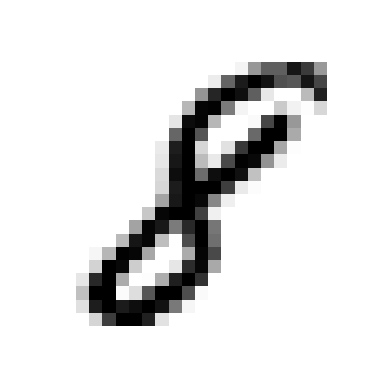

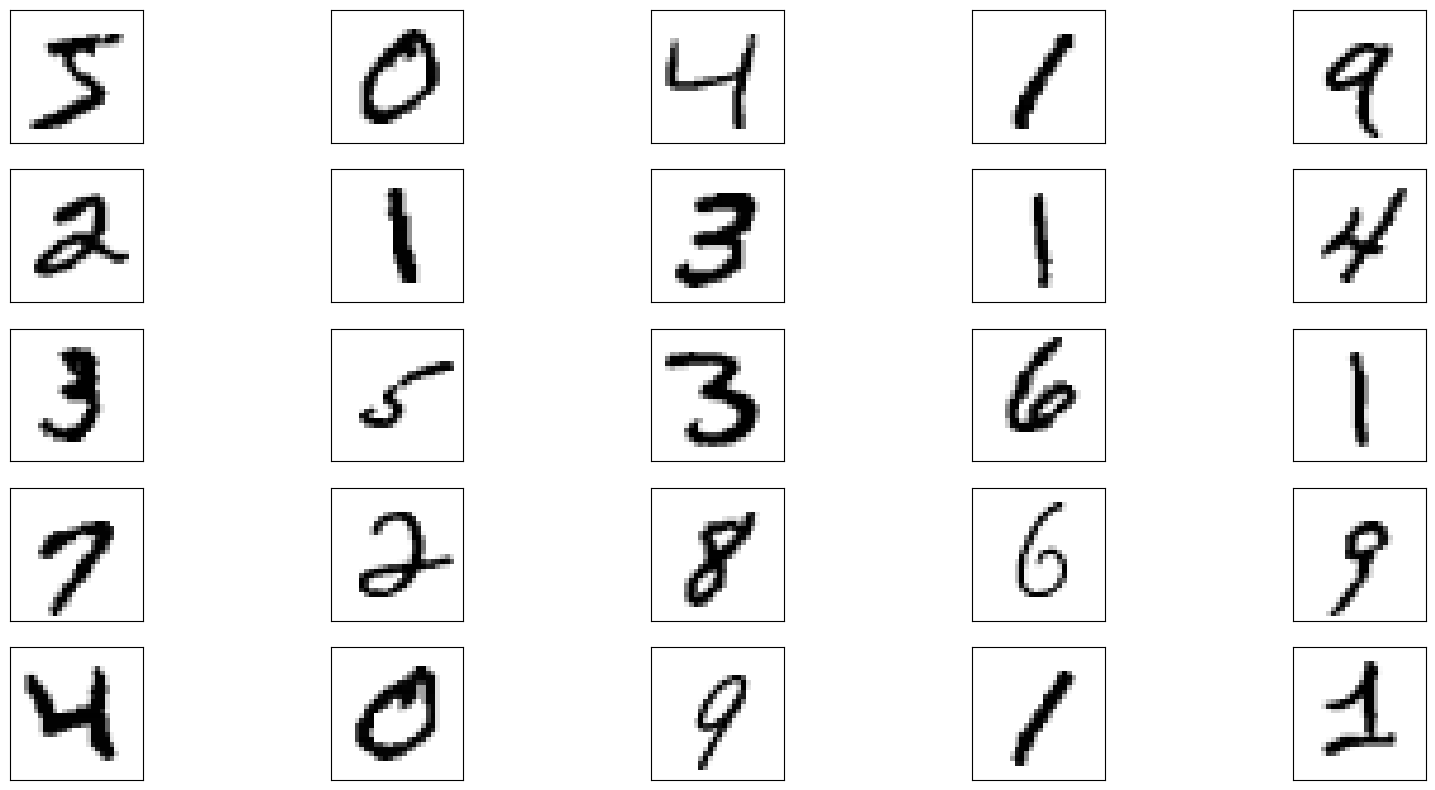

In [ ]:

print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

print(x_train[7777])

print(y_train[7777])

print(y_train_cat[7777])

plt.imshow(x_train[7777], cmap='binary')
plt.axis('off')
plt.show()

plt.figure(figsize=(20,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[i], cmap=plt.cm.binary)
plt.show()

In [ ]:
model = keras.Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
    ])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
    )

history = model.fit(
    x_train, y_train_cat,
    batch_size=32,
    epochs=20,
    validation_split=0.2
    )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8605 - loss: 0.4882 - val_accuracy: 0.9552 - val_loss: 0.1573
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9607 - loss: 0.1336 - val_accuracy: 0.9669 - val_loss: 0.1141
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9738 - loss: 0.0871 - val_accuracy: 0.9708 - val_loss: 0.0992
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9810 - loss: 0.0649 - val_accuracy: 0.9728 - val_loss: 0.0877
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9862 - loss: 0.0487 - val_accuracy: 0.9719 - val_loss: 0.0930
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9900 - loss: 0.0354 - val_accuracy: 0.9740 - val_loss: 0.0829
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9925 - loss: 0.0258 - val_accuracy: 0.9720 - val_loss: 0.0989
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9937 - loss: 0.0223 - 

In [ ]:
print('train:', model.evaluate(x_train, y_train_cat, verbose = 0))
print('test:', model.evaluate(x_test, y_test_cat, verbose = 0))
print( 'val_loss:', np.argmin(history.history['val_loss']), history.history['val_loss'][np.argmin(history.history['val_loss'])] )
print( 'val_accuracy:', np.argmax(history.history['val_accuracy']), history.history['val_accuracy'][np.argmax(history.history['val_accuracy'])] )

train: [0.02545420452952385, 0.994949996471405]
test: [0.10300403088331223, 0.9783999919891357]
val_loss: 5 0.08287311345338821
val_accuracy: 19 0.9781666398048401


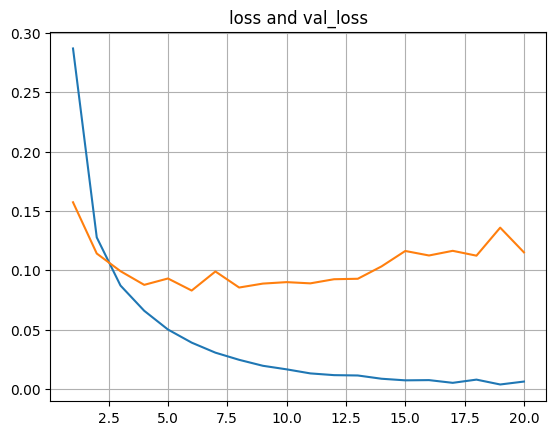

In [ ]:
plt.plot(list(range(1,len(history.history['loss'])+1)),history.history['loss'])
plt.plot(list(range(1,len(history.history['val_loss'])+1)),history.history['val_loss'])
plt.title("loss and val_loss")
plt.grid(True)
plt.show()

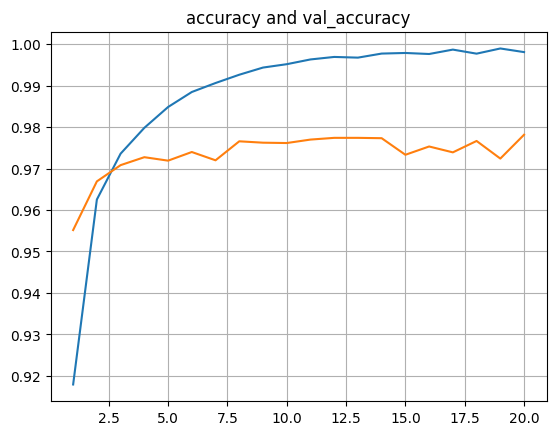

In [ ]:
plt.plot(list(range(1,len(history.history['accuracy'])+1)),history.history['accuracy'])
plt.plot(list(range(1,len(history.history['val_accuracy'])+1)),history.history['val_accuracy'])
plt.title("accuracy and val_accuracy")
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from keras.datasets import mnist

from keras.callbacks import ReduceLROnPlateau
from keras.callbacks import ModelCheckpoint

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Преобразуем данные в интервал [0,1]
x_train = x_train / 255
x_test = x_test / 255

y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.   

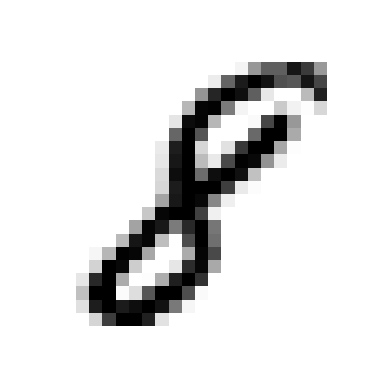

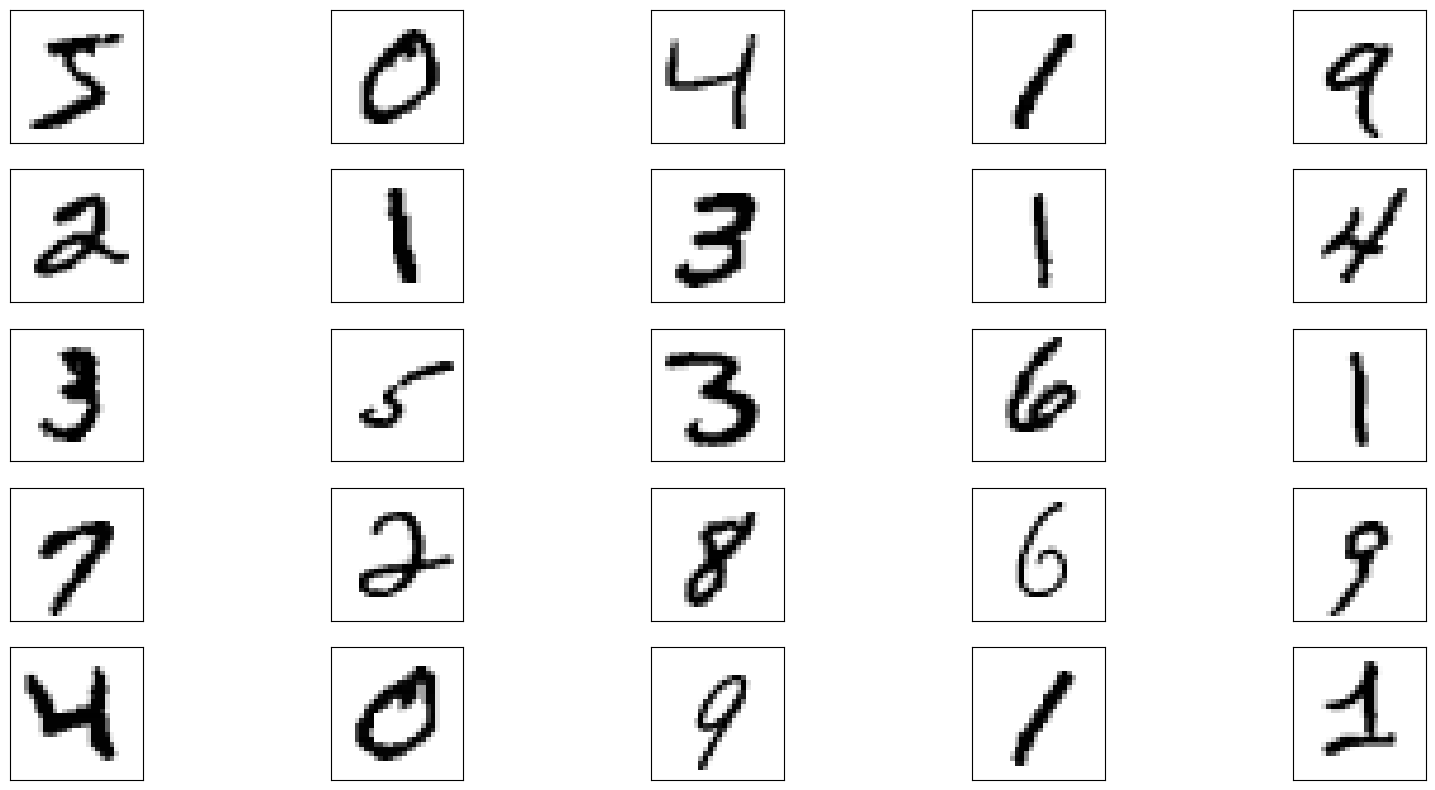

In [ ]:
# проверяем формы
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

# выводим выбранный вектор данных из обучающей выборки
print(x_train[7777])

# выводим метку класса
print(y_train[7777])

# выводим метку класса в one-hot-codding
print(y_train_cat[7777])

# Выводим выбранное изображение
plt.imshow(x_train[7777], cmap='binary')
plt.axis('off') # без осей
plt.show()

# Выводим первых 25 изображений из обучающей выборки
plt.figure(figsize=(20,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[i], cmap=plt.cm.binary)
plt.show()

In [ ]:
model = keras.Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
    ])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
    )

history = model.fit(
    x_train, y_train_cat,
    batch_size=32,
    epochs=50,
    validation_split=0.2
    )

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8674 - loss: 0.4756 - val_accuracy: 0.9568 - val_loss: 0.1514
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9605 - loss: 0.1372 - val_accuracy: 0.9628 - val_loss: 0.1207
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9728 - loss: 0.0920 - val_accuracy: 0.9696 - val_loss: 0.0986
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9808 - loss: 0.0639 - val_accuracy: 0.9712 - val_loss: 0.0979
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9865 - loss: 0.0467 - val_accuracy: 0.9707 - val_loss: 0.0957
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9894 - loss: 0.0364 - val_accuracy: 0.9755 - val_loss: 0.0845
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9917 - loss: 0.0293 - val_accuracy: 0.9743 - val_loss: 0.0861
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9933 - loss: 0.0224 -

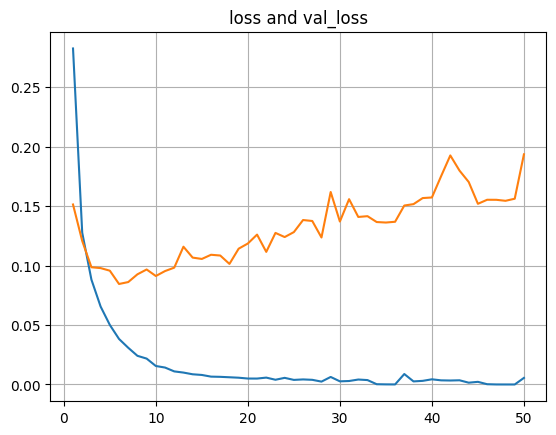

In [ ]:
plt.plot(list(range(1,len(history.history['loss'])+1)),history.history['loss'])
plt.plot(list(range(1,len(history.history['val_loss'])+1)),history.history['val_loss'])
plt.title("loss and val_loss")
plt.grid(True)
plt.show()

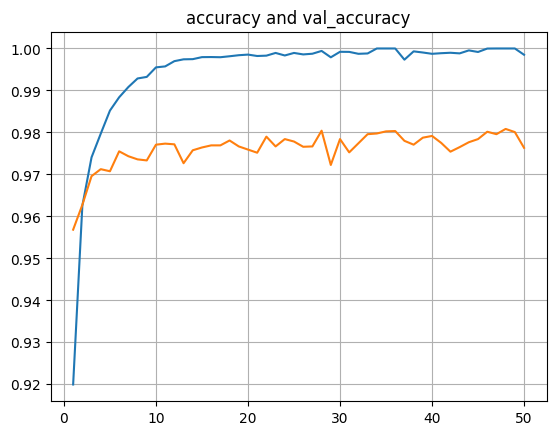

In [ ]:
plt.plot(list(range(1,len(history.history['accuracy'])+1)),history.history['accuracy'])
plt.plot(list(range(1,len(history.history['val_accuracy'])+1)),history.history['val_accuracy'])
plt.title("accuracy and val_accuracy")
plt.grid(True)
plt.show()

(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)
[[[0.43921569 0.39215686 0.39215686]
  [0.39607843 0.3254902  0.3372549 ]
  [0.42352941 0.34117647 0.34509804]
  ...
  [0.05490196 0.05882353 0.04313725]
  [0.07058824 0.07058824 0.03529412]
  [0.09803922 0.10196078 0.05882353]]

 [[0.64705882 0.60784314 0.61568627]
  [0.61960784 0.55686275 0.57647059]
  [0.65490196 0.57647059 0.58431373]
  ...
  [0.0627451  0.06666667 0.04705882]
  [0.05098039 0.05490196 0.02745098]
  [0.0745098  0.07843137 0.05882353]]

 [[0.70196078 0.71764706 0.73333333]
  [0.65882353 0.66666667 0.68627451]
  [0.63529412 0.63921569 0.64313725]
  ...
  [0.09019608 0.09411765 0.10196078]
  [0.05490196 0.05490196 0.04313725]
  [0.08235294 0.08235294 0.06666667]]

 ...

 [[0.07058824 0.07058824 0.05098039]
  [0.08235294 0.07843137 0.04705882]
  [0.10588235 0.09411765 0.05490196]
  ...
  [0.70588235 0.64313725 0.61176471]
  [0.70980392 0.65098039 0.62745098]
  [0.72156863 0.6627451  0.63529412]]

 [[0.10980392 

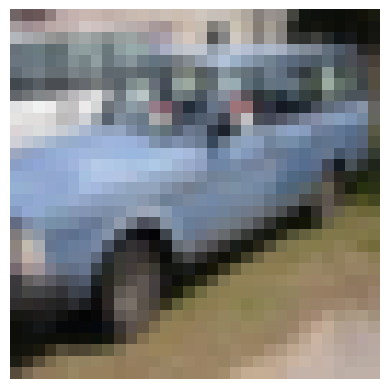

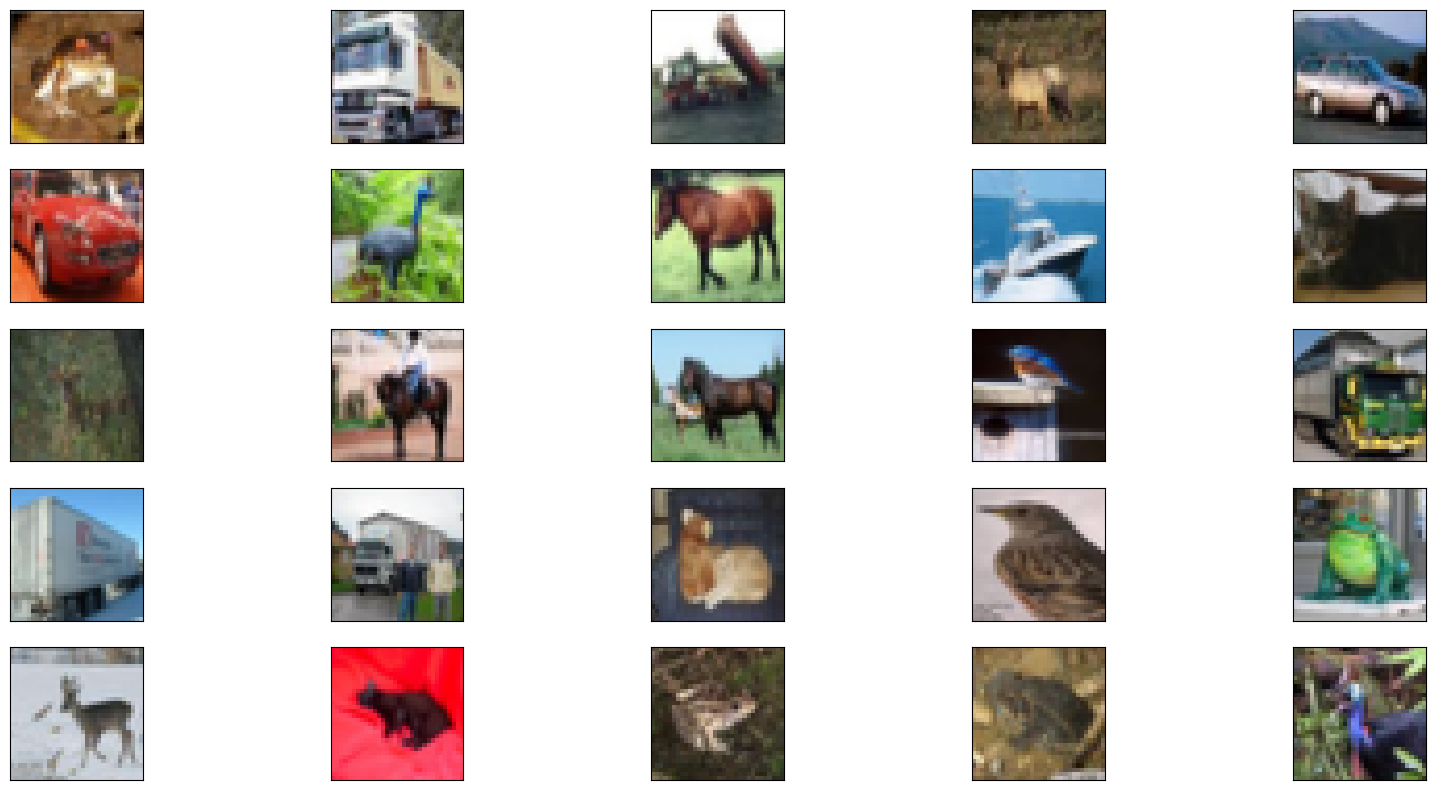

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.2671 - loss: 2.0344 - val_accuracy: 0.3410 - val_loss: 1.8285
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3542 - loss: 1.7793 - val_accuracy: 0.3674 - val_loss: 1.7745
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3749 - loss: 1.7406 - val_accuracy: 0.3708 - val_loss: 1.7603
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3942 - loss: 1.6970 - val_accuracy: 0.3862 - val_loss: 1.7340
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3968 - loss: 1.6765 - val_accuracy: 0.3860 - val_loss: 1.7229
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3985 - loss: 1.6667 - val_accuracy: 0.3882 - val_loss: 1.7373
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4043 - loss: 1.6588 - val_accuracy: 0.3923 - val_loss: 1.7226
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4116 - loss: 1.6549 - 

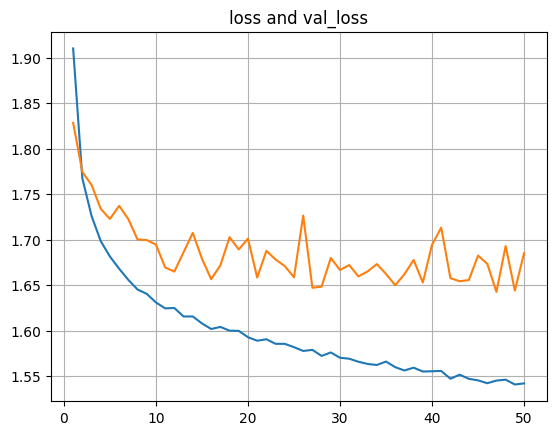

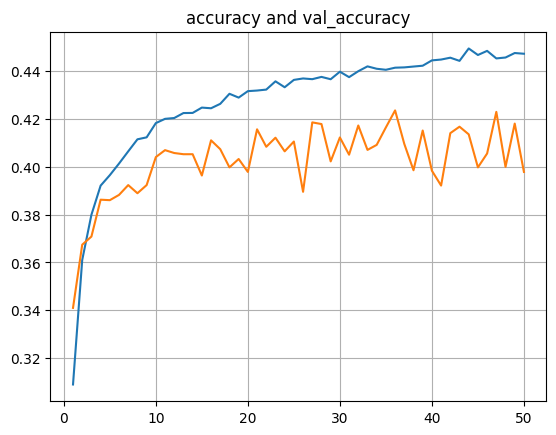

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
# Импортируем cifar10 вместо mnist
from keras.datasets import cifar10

from keras.callbacks import ReduceLROnPlateau
from keras.callbacks import ModelCheckpoint

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train / 255
x_test = x_test / 255

y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

print(x_train[7777])

print(y_train[7777])

print(y_train_cat[7777])

plt.imshow(x_train[7777])
plt.axis('off')
plt.show()

plt.figure(figsize=(20,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[i])
plt.show()

model = keras.Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
    ])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
    )

history = model.fit(
    x_train, y_train_cat,
    batch_size=32,
    epochs=50,
    validation_split=0.2
    )

plt.plot(list(range(1,len(history.history['loss'])+1)),history.history['loss'])
plt.plot(list(range(1,len(history.history['val_loss'])+1)),history.history['val_loss'])
plt.title("loss and val_loss")
plt.grid(True)
plt.show()

plt.plot(list(range(1,len(history.history['accuracy'])+1)),history.history['accuracy'])
plt.plot(list(range(1,len(history.history['val_accuracy'])+1)),history.history['val_accuracy'])
plt.title("accuracy and val_accuracy")
plt.grid(True)
plt.show()

Размер обучающей выборки: (50000, 32, 32, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,250,858 (4.77 MB)

 Trainable params: 1,250,858 (4.77 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.3095 - loss: 1.8638 - val_accuracy: 0.5605 - val_loss: 1.2346
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5664 - loss: 1.2167 - val_accuracy: 0.6528 - val_loss: 0.9919
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6348 - loss: 1.0353 - val_accuracy: 0.6942 - val_loss: 0.8617
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6740 - loss: 0.9219 - val_accuracy: 0.7144 - val_loss: 0.8162
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7027 - loss: 0.8387 - val_accuracy: 0.7420 - val_loss: 0.7552
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7250 - loss: 0.7841 - val_accuracy: 0.7401 - val_loss: 0.7406
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7405 - loss: 0.7375 - val_accuracy: 0.7562 - val_loss: 0.6992
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7605 - loss: 0.6833 - val_accuracy: 0

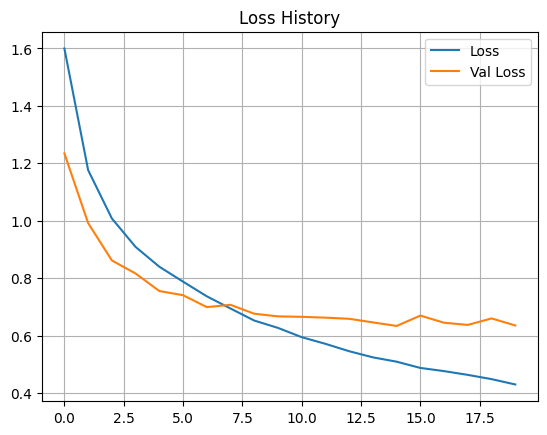

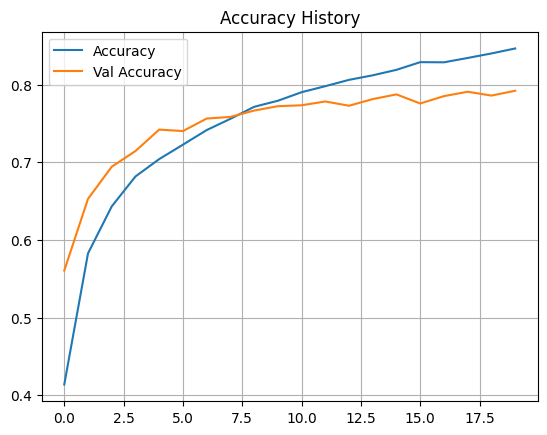

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import keras
from keras.models import Sequential
# Добавляем Conv2D и MaxPooling2D
from keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D
from keras.datasets import cifar10

from keras.callbacks import ReduceLROnPlateau
from keras.callbacks import ModelCheckpoint

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train / 255
x_test = x_test / 255

y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

print("Размер обучающей выборки:", x_train.shape)

model = keras.Sequential([
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
    )

# бучение
history = model.fit(
    x_train, y_train_cat,
    batch_size=64,
    epochs=20,
    validation_split=0.2
    )

# 5. Графики
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss History")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy History")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Загружаем данные MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

def find_digit_samples(digits):
    samples = []
    for digit in digits:
        indices = np.where(y_train == digit)[0]
        sample = x_train[indices[0]]
        samples.append(sample)
    return samples

digit_1, digit_5 = find_digit_samples([1, 5])

def linear_interpolate(img1, img2, num_steps):
    """Линейная интерполяция между двумя изображениями"""
    interpolated = []
    for alpha in np.linspace(0, 1, num_steps):
        interp_img = (1 - alpha) * img1 + alpha * img2
        interpol

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from keras import backend as K
import tensorflow as tf
sess = tf.Session()
K.set_session(sess)

In [ ]:
batch_size = 256
batch_shape = (batch_size, 28, 28, 1)
latent_dim = 2
num_classes = 10
dropout_rate = 0.3

In [ ]:
def gen_batch(x, y):
    n_batches = x.shape[0] // batch_size
    while(True):
        for i in range(n_batches):
            yield x[batch_size*i: batch_size*(i+1)], y[batch_size*i: batch_size*(i+1)]
        idxs = np.random.permutation(y.shape[0])
        x = x[idxs]
        y = y[idxs]


train_batches_it = gen_batch(x_train, y_train_cat)
test_batches_it  = gen_batch(x_test,  y_test_cat)

Загружен CIFAR10. Форма изображений: (32, 32, 3)
Начинаем обучение... Это займет время.
Эпоха 1, Gen Loss: 1.6520, Disc Loss: 0.7701, Время: 19.7 сек
Эпоха 2, Gen Loss: 1.5793, Disc Loss: 0.8594, Время: 14.7 сек
Эпоха 3, Gen Loss: 1.4885, Disc Loss: 0.9139, Время: 14.9 сек
Эпоха 4, Gen Loss: 1.4878, Disc Loss: 0.9155, Время: 14.2 сек
Эпоха 5, Gen Loss: 1.3928, Disc Loss: 0.9539, Время: 14.1 сек
Эпоха 6, Gen Loss: 1.4408, Disc Loss: 0.9318, Время: 14.4 сек
Эпоха 7, Gen Loss: 1.4648, Disc Loss: 0.9031, Время: 14.2 сек
Эпоха 8, Gen Loss: 1.2045, Disc Loss: 1.0749, Время: 14.3 сек
Эпоха 9, Gen Loss: 1.2257, Disc Loss: 1.0601, Время: 14.3 сек
Эпоха 10, Gen Loss: 1.2817, Disc Loss: 0.9839, Время: 20.5 сек
Эпоха 11, Gen Loss: 1.5476, Disc Loss: 0.9129, Время: 14.2 сек
Эпоха 12, Gen Loss: 1.3778, Disc Loss: 0.9669, Время: 14.3 сек
Эпоха 13, Gen Loss: 1.3665, Disc Loss: 1.0234, Время: 14.3 сек
Эпоха 14, Gen Loss: 1.3305, Disc Loss: 1.0406, Время: 14.3 сек
Эпоха 15, Gen Loss: 1.3287, Disc Loss: 

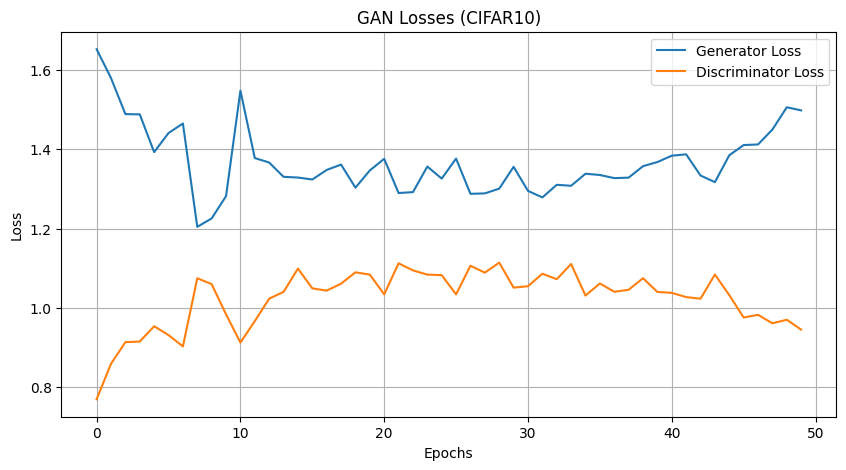

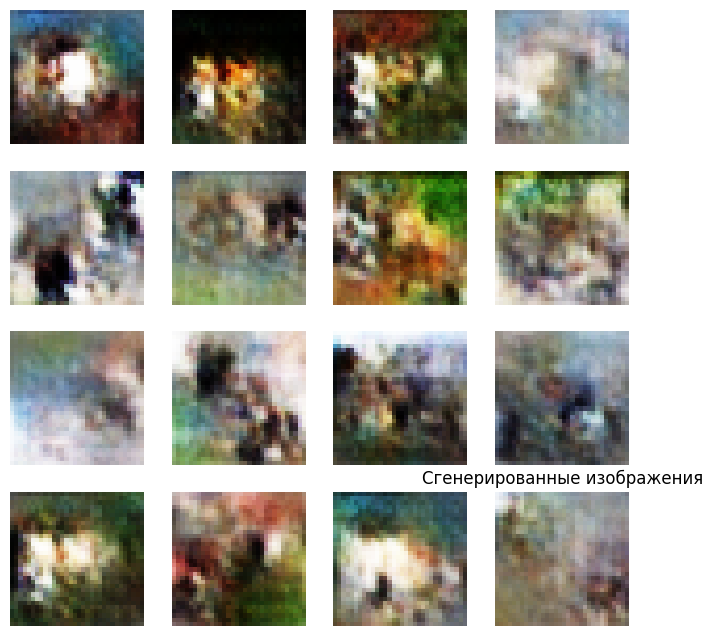

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import time

DATASET_NAME = 'CIFAR10'
EPOCHS = 50
BATCH_SIZE = 64
NOISE_DIM = 100

def load_data(dataset_name):
    if dataset_name == 'CIFAR10':
        (x_train, _), (_, _) = tf.keras.datasets.cifar10.load_data()
        channels = 3
    else:
        (x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
        x_train = np.expand_dims(x_train, axis=-1)
        x_train = tf.image.resize(x_train, [32, 32]).numpy()
        channels = 1

    x_train = (x_train - 127.5) / 127.5
    return x_train, channels

train_images, CHANNELS = load_data(DATASET_NAME)

train_dataset = tf.data.Dataset.from_tensor_slices(train_images)\
    .shuffle(train_images.shape[0]).batch(BATCH_SIZE)

print(f"Загружен {DATASET_NAME}. Форма изображений: {train_images.shape[1:]}")


def make_generator_model():
    model = tf.keras.Sequential()
    model.add(layers.Dense(4*4*256, use_bias=False, input_shape=(NOISE_DIM,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((4, 4, 256)))

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(CHANNELS, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    return model

def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[32, 32, CHANNELS]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))
    return model

generator = make_generator_model()
discriminator = make_discriminator_model()

cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

gen_losses = []
disc_losses = []

print("Начинаем обучение... Это займет время.")

for epoch in range(EPOCHS):
    start = time.time()
    epoch_gen_loss = []
    epoch_disc_loss = []

    for image_batch in train_dataset:
        g_loss, d_loss = train_step(image_batch)
        epoch_gen_loss.append(g_loss)
        epoch_disc_loss.append(d_loss)

    avg_g_loss = np.mean(epoch_gen_loss)
    avg_d_loss = np.mean(epoch_disc_loss)
    gen_losses.append(avg_g_loss)
    disc_losses.append(avg_d_loss)

    print(f'Эпоха {epoch + 1}, Gen Loss: {avg_g_loss:.4f}, Disc Loss: {avg_d_loss:.4f}, Время: {time.time()-start:.1f} сек')

plt.figure(figsize=(10, 5))
plt.plot(gen_losses, label="Generator Loss")
plt.plot(disc_losses, label="Discriminator Loss")
plt.title(f"GAN Losses ({DATASET_NAME})")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

noise = tf.random.normal([16, NOISE_DIM])
generated_images = generator(noise, training=False)

generated_images = (generated_images * 127.5 + 127.5) / 255.0

plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i+1)
    if CHANNELS == 1:
        plt.imshow(generated_images[i, :, :, 0], cmap='gray')
    else:
        plt.imshow(generated_images[i])
    plt.axis('off')
plt.title("Сгенерированные изображения")
plt.show()